# Prova de conceito: DoseEngine

Este notebook tem como propósito a exposição das ideias que serão aplicadas neste projeto, de forma mais direta, mais explicativa e com arquitetura mais simples. Apresenta um modelo bidimensional, relativo e estritamente didático, obviamente não validado clinicamente nem com objetivo de ser assim aplicado.

É fruto da compilação de vários protótipos prévios que guiaram as decisões tomadas na construção modular do programa apresentado no repositório.

## Objetivos da demonstração

* Construir um fantoma heterogéneo
* Calcular a profundidade radiológica
* Estimar a fluência primária
* Obter uma matriz relativa de TERMA
* Redestribuir a energia através de um kernel
* Analisar a distribuição de dose resultante

## Cálculo de dose

Em radioterapia externa são aplicadas doses de radiação que permitem destruir células cancerígenas.
A quantidade de radiação usada deve ser escolhida com precisão, de modo a resolver um problema de otimização: "Como eliminar eficazmente o tumor, mitigando ao máximo o dano em órgãos circundantes".

No âmbito deste projeto vamos focar-nos em radioterapia externa que usa fotões, ou seja, uma fonte externa (geralmente um LINAC) emite raios X na direção do tumor alvo do paciente.
Algoritmos de cálculo de dose, neste contexto, pretendem modelar a deposição da energia induzida pela radiação ionizante. Isto inclui modelar os fenómenos de interação fotão-matéria tais como efeito de Compton e efeito fotoelétrico, dependendo de fatores como a energia dos fotões e a densidade do meio com que interagem.

Ao longo dos anos, algoritmos que calculam estas doses, de modo a equilibrar o índice terapêutico, têm evoluído em termos de precisão.
Outro fator a ter em conta é o tempo e poder computacional usados para obter os resultados. Usando algoritmos de Monte Carlo é possível obter elevada precisão, simulando a natureza estocástica dos fenómenos de interação radiação-matéria, mas o tempo de computação tende a ser longo, havendo algoritmos mais rápidos sacrificando alguma precisão.

Neste projeto vamos focar-nos em algoritmos mais simples, que permitem obter os resultados em alguns segundos, explorando os fenómenos físicos associados e comparando os resultados das diferentes abordagens.

## Fantomas

Em ambiente clínico são usadas imagens de TAC (tomografia axial computorizada) dos pacientes para derivar o seu perfil de densidade eletrónica na zona circundante ao tumor. Esse processo vai ser desenvolvido neste projeto mas para introduzir a ideia vamos gerar fantomas.

O fantoma faz isto artificialmente, será, neste caso, uma matriz de numpy que caracteriza a densidade eletrónica do espaço. Dependendo do tecido presente a densidade é maior ou menor. Vamos assumir que o meio em geral é constituído por água (fantoma de água), já que os tecidos moles em geral possuem um comportamento radiológico semelhante, sendo atribuída uma densidade eletrónica relativa de valor $\rho_e^{rel} = 1$.

Vamos criar uma secção transversal de 20x40 cm. O caso de estudo será a interface tecido-pulmão. O pulmão, sendo preenchido por ar, tem uma densidade muito inferior à da água, o que altera drasticamente o transporte de radiação primária e o espalhamento de eletrões secundários.

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve2d

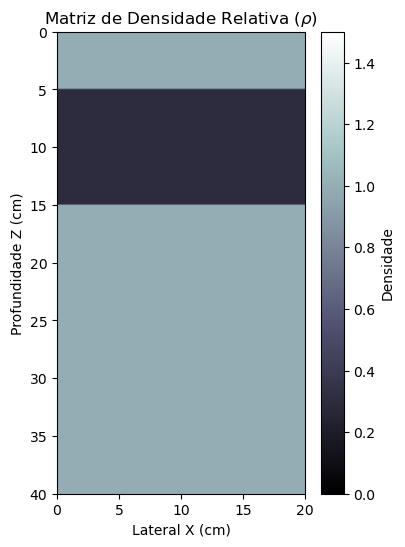

In [7]:
# Discretizar o domínio
dx, dz = 0.2, 0.2 # a nossa unidade na grelha será de 0.2 cm
nx, nz = 100, 200 # número de pixels nas duas direções

# Criar o fantoma de água
phantom = np.ones((nz, nx)) # neste momento o fantoma é homogéneo, a ordem é muito importante

# Inserir o órgão, neste caso um pulmão, no intervalo z = [5, 15] cm
z_i = int(5.0 / dz) # dividindo pela unidade de discretização podemos usar o valor em cm
z_f = int(15.0 / dz)
phantom[z_i: z_f, :] = 0.3

# Visualização do fantoma
plt.figure(figsize=(4,6))
plt.imshow(phantom, cmap='bone', extent=[0, nx*dx, nz*dz, 0], vmin=0, vmax=1.5, aspect="auto")
plt.title("Matriz de Densidade Relativa ($\\rho$)")
plt.colorbar(label="Densidade")
plt.ylabel("Profundidade Z (cm)")
plt.xlabel("Lateral X (cm)")
plt.show()



## Transporte primário e o conceito de TERMA

#### Contextualização:
Os primeiros algoritmos, que surgiram nos anos 40, conhecidos por "correction-based", usavam métricas comparativas para calcular as doses, obtendo-se baixa precisão. 

À medida que o hardware foi ficando mais poderoso, já a partir dos anos 80, entraram em desenvolvimento algoritmos que realmente simulavam a física da radiação designados "model-based", contando com uma maior precisão mas também muito variável face às aproximações utilizadas.

#### TERMA
Estes algoritmos mais modernos são baseados no conceito de TERMA, que significa: 
Total Energy Released in MAtter. É a energia por unidade de massa libertada no ponto de interação dos fotões primários: os provenientes da fonte externa.

Para calcular esta grandeza, tem-se em conta o número de fotões (fluência) do feixe primário, que vai diminuindo à medida que atravessa o corpo. A atenuação do feixe é regida pela lei de Beer-Lambert. Como o corpo tem órgãos de densidades diferentes vamos usar o conceito de profundidade radiológica: uma métrica que ajusta o percurso com base na densidade do meio. No nosso caso um pulmão, por ter menos densidade, atenua menos o feixe de radiação do que o restante tecido do fantoma.

Assim, o TERMA final vai resultar da energia transportada pelos fotões que resistem à viagem e o tipo de tecido onde incidem.

Nesta prova de conceito, o TERMA é representado por uma grandeza relativa proporcional à fluência primária atenuada e ao coeficiente de interação adotado. Não é realizada uma calibração absoluta de energia ou dose, sendo por isso simplificado o conceito.



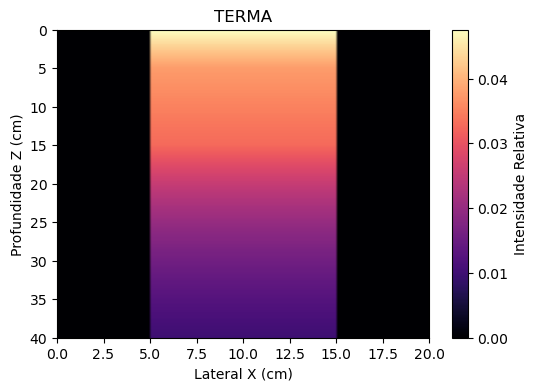

In [8]:
mu_water = 0.048 # coeficiente de atenuação linear estimado para 6 MV (em cm^-1)

# Calcular a profundidade radiológica acumulada linha a linha
d_eff = np.cumsum(phantom * dz, axis=0) # tem em conta a densidade variável do fantoma

# Calcular a fluência atenuada (usa-se um feixe 10x10 cm)
fluence = np.zeros((nz, nx))
center_x = nx // 2 # define-se o centro do fantoma
field_radius = int((10 / 2) / dx) # define-se o raio, ou meia-largura, tendo em conta o feixe escolhido

for z in range(nz):
    attenuation = np.exp(-mu_water * d_eff[z, center_x - field_radius : center_x + field_radius]) # lei de Beer-Lambert nos limites de aplicação do feixe
    fluence[z, center_x - field_radius : center_x + field_radius] = 1.0 * attenuation # toma-se o valor relativo da fluência como 1 na superfície inicial

# Calcular TERMA
terma = fluence * mu_water

# Visualização
plt.figure(figsize=(6, 4))
plt.imshow(terma, cmap='magma', extent=[0, nx*dx, nz*dz, 0], aspect="auto")
plt.title("TERMA")
plt.colorbar(label="Intensidade Relativa")
plt.ylabel("Profundidade Z (cm)")
plt.xlabel("Lateral X (cm)")
plt.show()

## O espalhamento secundário e Dose Spread Kernel (DSK)

DSK refere-se à descrição do transporte de energia por partículas secundárias, isto inclui fotões espalhados, eletrões que surgem no efeito de Compton, entre outros.

Ao contrário do TERMA, que nos diz qual é a energia libertada pelos fotões do feixe externo, a energia que é realmente depositada nos tecidos também é resultado dos eletrões secundários resultantes do efeito de Compton (neste caso específico é o efeito preponderante para um feixe externo de 6 MV), que vão depositando dose ao longo desse percurso.

Para modelar a deposição da dose usamos uma função:
$$K(r) = A \cdot e^{-a \cdot r} + B \cdot e^{-b \cdot r}$$
Significado físico dos termos:

**O Núcleo ($A$ e $a$):** O primeiro termo domina a região muito próxima da interação. Representa os eletrões secundários de curto alcance que depositam muita energia localmente.

**A Penumbra ($B$ e $b$):** O segundo termo tem um decaimento mais suave e representa a cauda de longo alcance, composta por fotões espalhados.


**O Efeito de Build-up :**
 Como a energia libertada à superfície é espalhada para a frente e para os lados, e não há tecido acima da pele para gerar retroespalhamento de volta para a superfície, a dose na pele é baixa. A dose vai acumulando (*build-up*) à medida se desce em profundidade, até atingir um máximo em $d_{max}.$

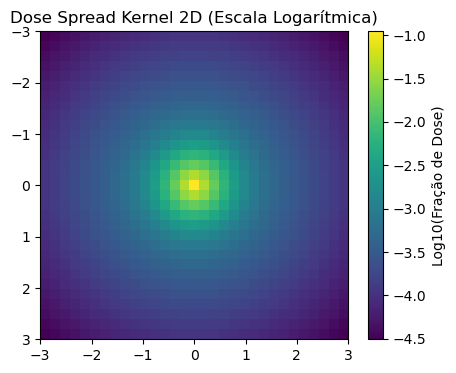

In [9]:
# Parâmetros da dupla exponencial (Ajustados paraproduzir visualização qualitativamente plausivel mas didática)
A, a = 1.0, 5.0
B, b = 0.02, 1.0  

# Definir a matriz do Kernel (ex: raio máximo de 3 cm de espalhamento)
kernel_radius_cm = 3.0
kernel_pixels = int(kernel_radius_cm / dx)
kernel_size = (2 * kernel_pixels) + 1

# Criar a malha de distâncias radiais (r)
x_k = np.arange(kernel_size) - kernel_pixels
z_k = np.arange(kernel_size) - kernel_pixels
xx, zz = np.meshgrid(x_k, z_k)

# Distância geométrica de cada píxel ao centro
r = np.sqrt(xx**2 + zz**2) * dx

# Calcular a mancha térmica e normalizar (conservação de energia)
kernel_matrix = A * np.exp(-a * r) + B * np.exp(-b * r)
kernel_matrix = kernel_matrix / np.sum(kernel_matrix)

# Visualização do Kernel (em escala logarítmica caso contrário apenas se iria notar o centro)
plt.figure(figsize=(5, 4))
plt.imshow(np.log10(kernel_matrix), cmap='viridis', extent=[-kernel_radius_cm, kernel_radius_cm, kernel_radius_cm, -kernel_radius_cm])
plt.title("Dose Spread Kernel 2D (Escala Logarítmica)")
plt.colorbar(label="Log10(Fração de Dose)")
plt.show()

## Convolução: O Cálculo da Dose Final

Para unir as duas contribuições: fotões primários e espalhamento de partículas secundárias, representadas pelo TERMA e DSK, respetivamente, vamos usar uma convolução.

O kernel que modelamos vai ser "carimbado" ao longo dos pixels onde incide o TERMA, para modelar o espalhamento e representar a dose total que é a soma sobreposta destes "carimbos"

Matematicamente, para um meio homogéneo, a dose $D(r)$ num ponto é dada pela convolução entre o TERMA e o kernel:

$$D(r) = TERMA \otimes K(r)$$

**Nota sobre o modelo simples aqui usado:**
Nesta demonstração, utiliza-se um kernel que não altera o seu formato e tamanho consoante a densidade local (invariância espacial). Esta é uma aproximação clássica de meios homogéneos. Embora o nosso cálculo de Fluência tenha em conta a densidade do pulmão (através da profundidade radiológica), a fase de espalhamento secundário assume que os eletrões viajam como se estivessem em água. Em sistemas clínicos mais avançados, o kernel é escalado dinamicamente para "esticar" no pulmão e "encolher" no osso.

Apesar desta simplificação, a convolução permite-nos observar fenómenos físicos cruciais da radioterapia, como o efeito de *build-up* na superfície.

Nas representações que se seguem usa-se o conceito de PDD: percentage depth dose, que nos diz como varia a dose à medida que o feixe viaja em profundidade, que terá um máximo não na pele mas sim depois, em $d_{max}$ como já foi explicado, que para 6 MV é cerca de 1,5 cm.

O perfil lateral mostra como a dose se distribuiu horizontalmente em intensidade (neste caso na profundidade do meio do pulmão), caindo abruptamente nas bordas mas ainda com alguma intensidade derivada do espalhamento das partículas secundárias.

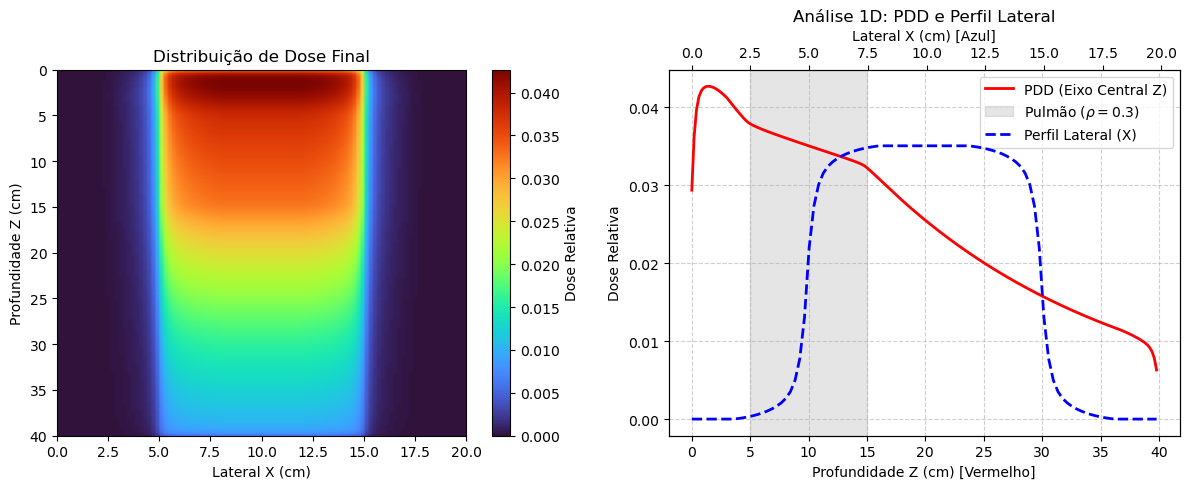

In [10]:
# Aplicar o operador matemático de convolução
dose_final = convolve2d(terma, kernel_matrix, mode='same', boundary='fill', fillvalue=0) # 'mode=same' mantém as dimensões originais do paciente

# Visualização da Dose Final
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# Mapa de Cores da Dose
im = axs[0].imshow(dose_final, cmap='turbo', extent=[0, nx*dx, nz*dz, 0], aspect='auto')
axs[0].set_title("Distribuição de Dose Final")
axs[0].set_xlabel("Lateral X (cm)")
axs[0].set_ylabel("Profundidade Z (cm)")
fig.colorbar(im, ax=axs[0], label="Dose Relativa")

# Análise Quantitativa (PDD e Perfil Lateral)
eixo_z = np.arange(nz) * dz
eixo_x = np.arange(nx) * dx

# PDD no eixo central e Perfil Lateral aos 10 cm de profundidade (meio do pulmão)
pdd = dose_final[:, nx // 2]
perfil_lateral = dose_final[int(10.0 / dz), :]

axs[1].plot(eixo_z, pdd, 'r-', linewidth=2, label="PDD (Eixo Central Z)")
axs[1].axvspan(5.0, 15.0, color='gray', alpha=0.2, label="Pulmão ($\\rho=0.3$)")

# Eixo secundário para o Perfil Lateral
ax2 = axs[1].twiny()
ax2.plot(eixo_x, perfil_lateral, 'b--', linewidth=2, label="Perfil Lateral (X)")

axs[1].set_title("Análise 1D: PDD e Perfil Lateral")
axs[1].set_xlabel("Profundidade Z (cm) [Vermelho]")
axs[1].set_ylabel("Dose Relativa")
ax2.set_xlabel("Lateral X (cm) [Azul]")
axs[1].grid(True, linestyle='--', alpha=0.6)

# Unir as legendas num só bloco
lines_1, labels_1 = axs[1].get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
axs[1].legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper right')

plt.tight_layout()
plt.show()

## Conclusão e limitações

Esta demonstração mostra que um processo simplificado de cálculo de dose pode ser construído através da combinação de atenuação primária e convolução com um kernel de deposição de energia.

 A presença de um pulmão altera a profundidade radiológica e, consequentemente, a fluência e o TERMA calculados. No entanto, o kernel utilizado é espacialmente invariante e não adapta o transporte lateral à densidade local. Os resultados devem, portanto, ser interpretados qualitativamente.